In [21]:
#libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


In [22]:
#data loading

data1 = pd.read_csv('train.csv')
data2 = pd.read_csv('test.csv')

train_df = data1.copy()
test_df = data2.copy()

print("First 5 rows of train_df: \n", train_df.head())

print("First 5 rows of test_df: \n", test_df.head())

First 5 rows of train_df: 
    id  annual_income  debt_to_income_ratio  credit_score  loan_amount  \
0   0       29367.99                 0.084           736      2528.42   
1   1       22108.02                 0.166           636      4593.10   
2   2       49566.20                 0.097           694     17005.15   
3   3       46858.25                 0.065           533      4682.48   
4   4       25496.70                 0.053           665     12184.43   

   interest_rate  gender marital_status education_level employment_status  \
0          13.67  Female         Single     High School     Self-employed   
1          12.92    Male        Married        Master's          Employed   
2           9.76    Male         Single     High School          Employed   
3          16.10  Female         Single     High School          Employed   
4          10.21    Male        Married     High School          Employed   

         loan_purpose grade_subgrade  loan_paid_back  
0              

In [23]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB


In [24]:
train_df = train_df.drop(columns=['id'], axis=1)

test_id_placeholder = test_df['id']
test_df = test_df.drop(columns=['id'], axis=1)

In [25]:
num = train_df.select_dtypes(include='number')
cat = train_df.select_dtypes(exclude='number')

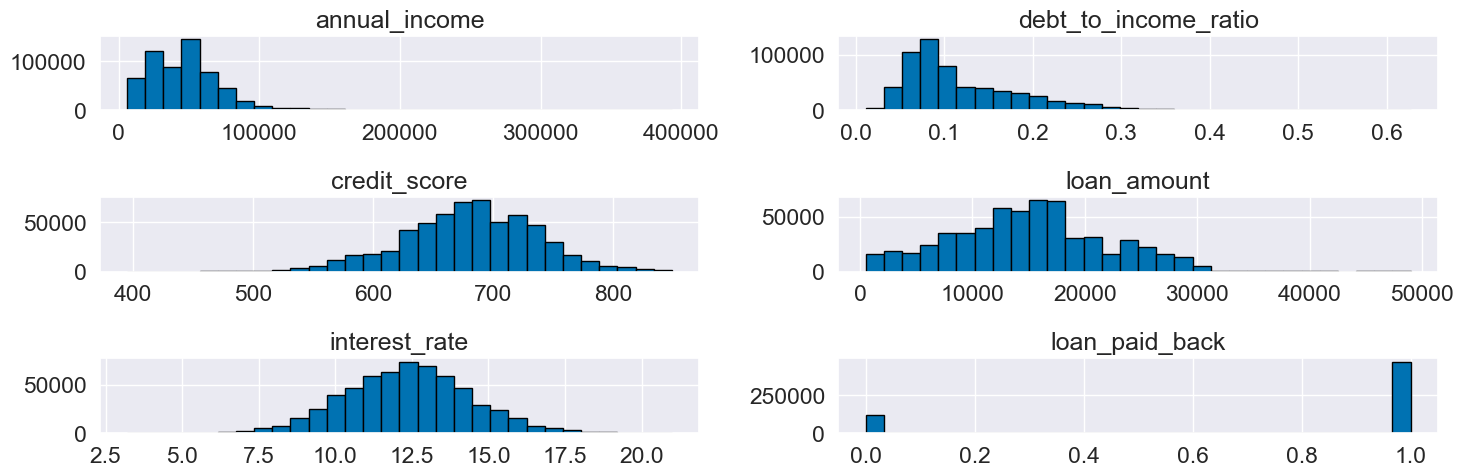

In [26]:
#plot numerical features

color = '#0072B2'

# grid size
nrows, ncols = 5, 2

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 8))

axes = axes.flatten()

# Plot each numerical feature
for i, ax in enumerate(axes):
    if i >= len(num.columns):
        ax.set_visible(False)  # hide unesed plots
        continue
    ax.hist(num.iloc[:, i], bins=30, color=color, edgecolor='black')
    ax.set_title(num.columns[i])

plt.tight_layout()
plt.show()


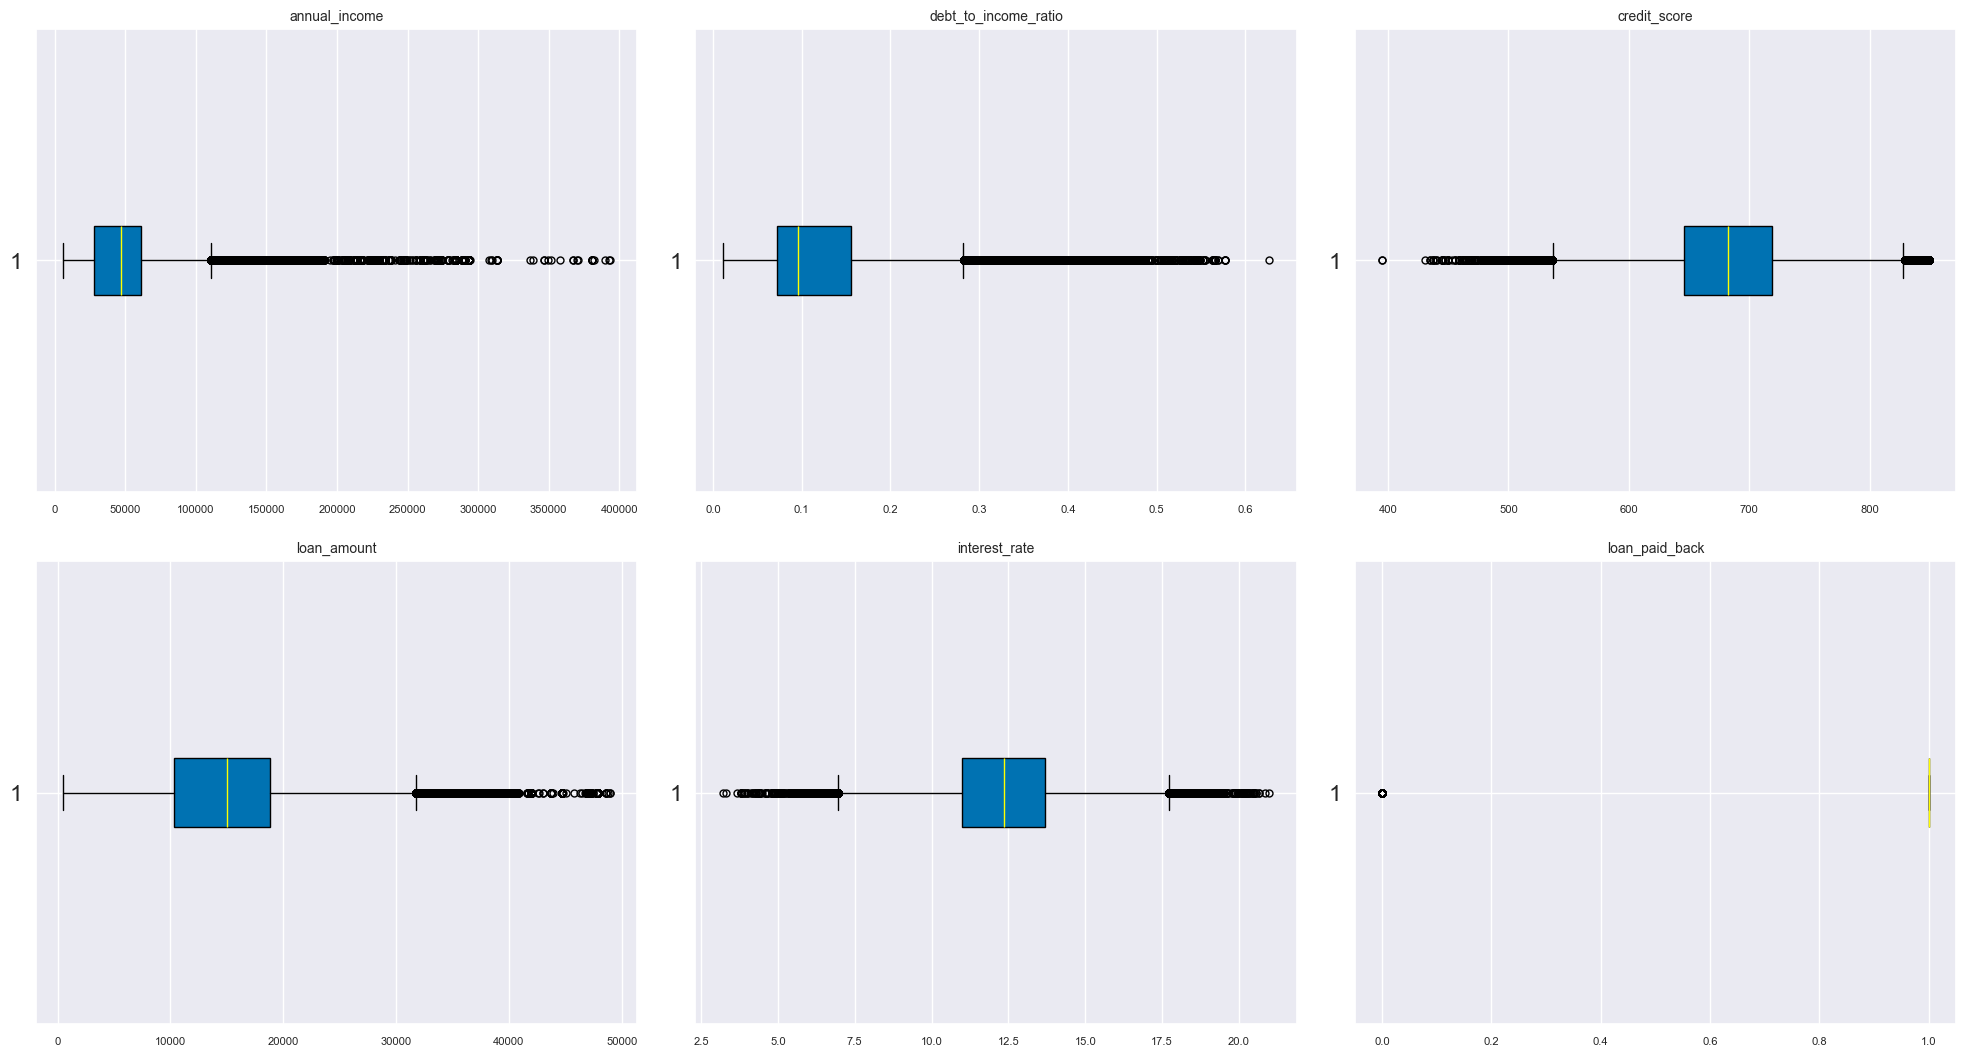

In [27]:
#boxplot numerical features

color = '#0072B2'

# grid size
nrows, ncols = 3, 3 

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 16))

axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(num.columns):
        ax.set_visible(False)
        continue
    ax.boxplot(num.iloc[:, i].dropna(), vert=False, patch_artist=True, 
               boxprops=dict(facecolor=color, color='black'), 
               medianprops=dict(color='yellow'), whiskerprops=dict(color='black'), 
               capprops=dict(color='black'), flierprops=dict(marker='o', color='red', markersize=5))
    ax.set_title(num.columns[i], fontsize=10)
    ax.tick_params(axis='x', labelsize=8)

plt.tight_layout()
plt.show()


In [28]:
no_payback = train_df[train_df['loan_paid_back'] == 0]
payback = train_df[train_df['loan_paid_back'] == 1]

In [29]:
print(no_payback[['education_level', 'annual_income']])

       education_level  annual_income
1             Master's       22108.02
14          Bachelor's       22790.15
17          Bachelor's       35268.70
22         High School      135416.72
26            Master's       24001.73
...                ...            ...
593966      Bachelor's       18217.07
593970     High School       67431.54
593971     High School       52448.82
593980     High School       24990.57
593986      Bachelor's       25015.35

[119500 rows x 2 columns]


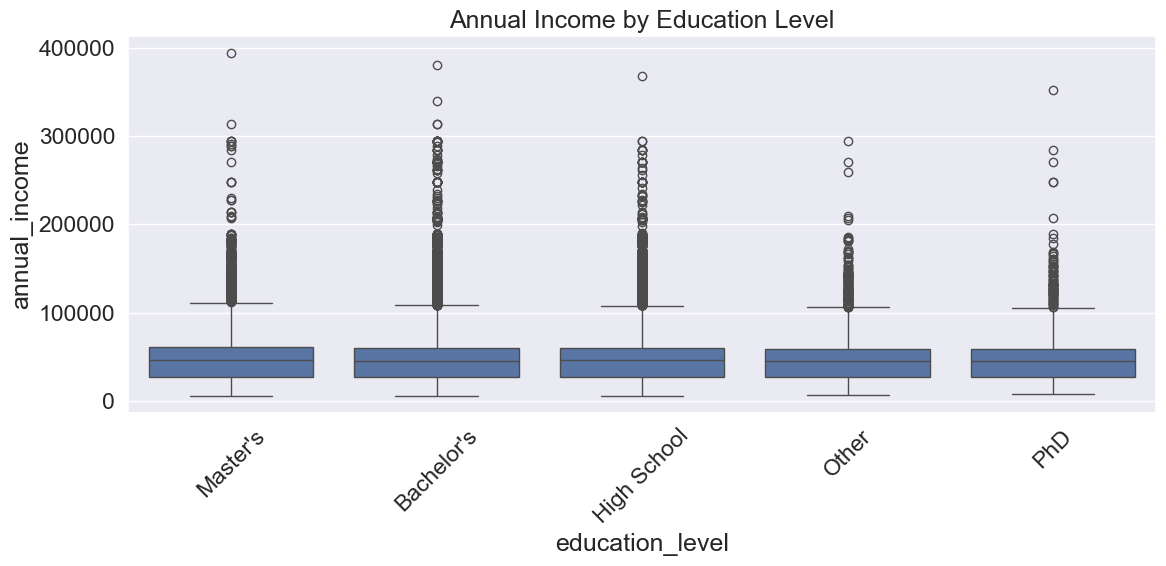

In [30]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=no_payback, x='education_level', y='annual_income')
plt.title('Annual Income by Education Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

There are some extreme outliers in the dataframe. This is going to impact on the performance of linear regression models.

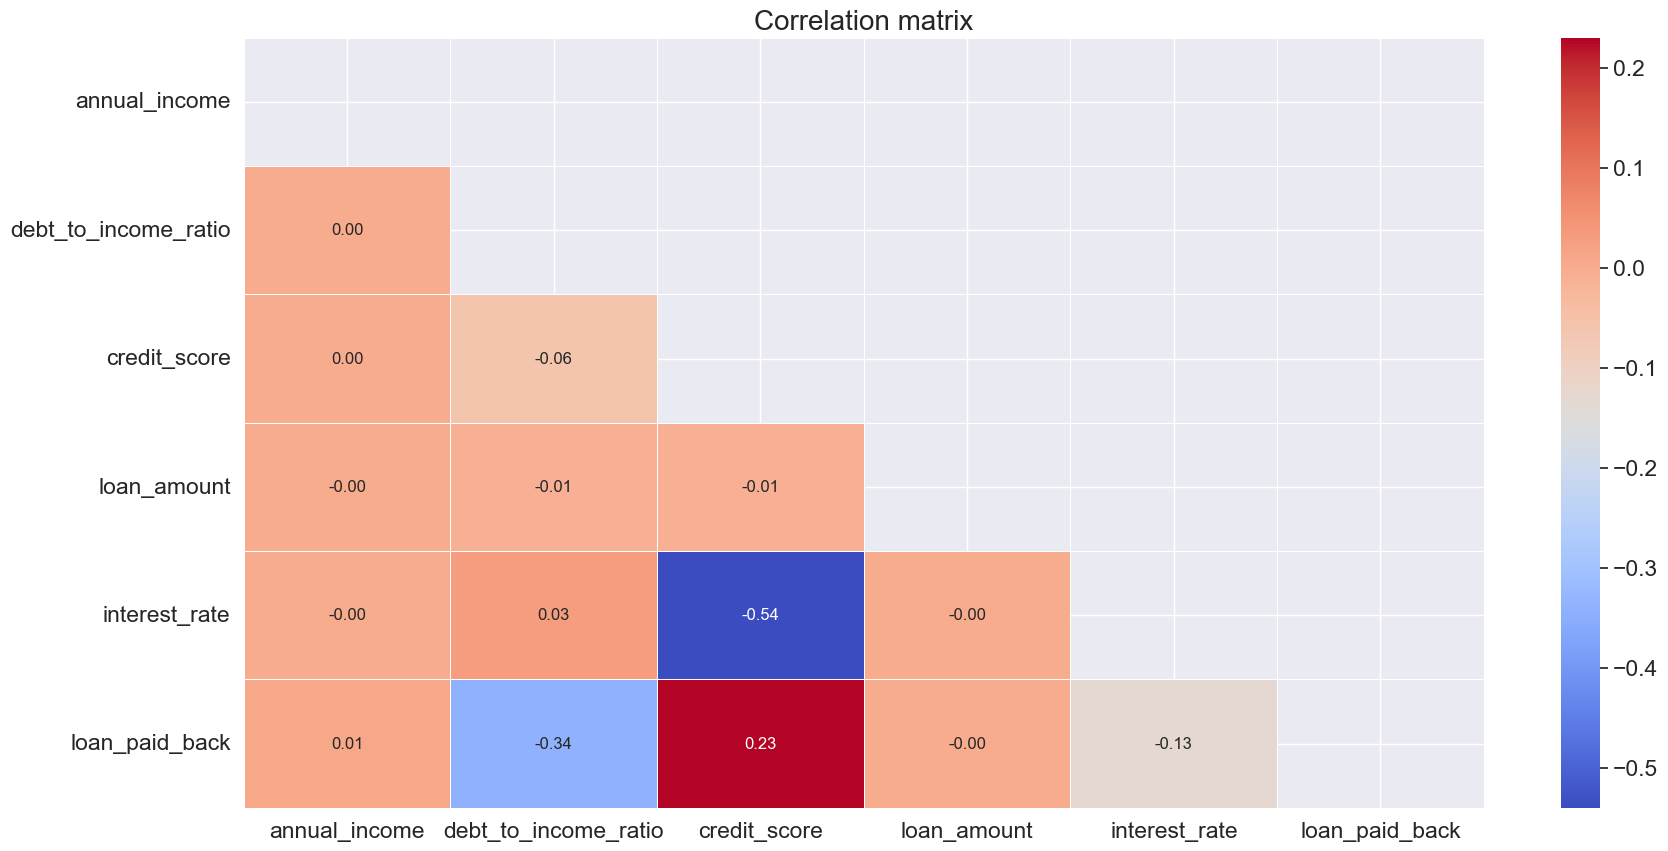

In [31]:
num1 = round(num.corr(), 2)

# Correlation Matrix-Heatmap Plot
mask = np.zeros_like(num1)
mask[np.triu_indices_from(mask)] = True # optional, to hide repeat half of the matrix

f, ax = plt.subplots(figsize=(20, 10))
sns.set_theme(font_scale=1.5) # increase font size

ax = sns.heatmap(num1, mask=mask, annot=True, annot_kws={"size": 12}, linewidths=.5, cmap="coolwarm", fmt=".2f", ax=ax) # round to 2 decimal places
ax.set_title("Correlation matrix", fontsize=20) # add title
plt.show()


The features which are more correlated to the loans being paid back are credit score and debt to income ratio.
Correlation is mild so I can create baseline models and then proceed to feature engineering to create new KPIs which hold higher correlation with the target.

The baseline won't hold categorical features.

In [32]:
train_numeric = train_df.select_dtypes(include='number')
test_numeric = test_df.select_dtypes(include='number')

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, f1_score


In [34]:
X = train_numeric.drop(columns=['loan_paid_back'])
y = train_numeric['loan_paid_back']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
#classification issues
def train_and_eval_models(X_train, X_test, y_train, y_test):

    #models to test
    models = {
        "Logistic Regression" : LogisticRegression(),
        "Random Forest" : RandomForestClassifier(),
        "XGB" : XGBClassifier()
    }

    print("Starting the training process.")

    #list to store results

    results = []

    #scaling data just for LogisticRegression

    for name, model in models.items():
        if name in ['Logistic Regression']:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            print(f"Features scaled for model {name}")

        print(f"Training model: {name}")

        model.fit(X_train_scaled, y_train)

        y_train_predict = model.predict(X_train_scaled) #to test accuracy on the train dataframe
        y_test_predict = model.predict(X_test_scaled)

        results.append({
            "Model" : name,
            "Train Accuracy" : accuracy_score(y_train, y_train_predict),
            "Test Accuracy" : accuracy_score(y_test, y_test_predict),
            "Train Precision" : precision_score(y_train, y_train_predict),
            "Test Precision" : precision_score(y_test, y_test_predict),
            "Train F1 Score" : f1_score(y_train, y_train_predict),
            "Test F1 Score" : f1_score(y_test, y_test_predict)
        })

    #Convering result into a df
    results_df = pd.DataFrame(results)
    print("\n Model Performance Summary: ")
    print(results_df)
    

    return results_df, model


In [37]:
results_df, model = train_and_eval_models(X_train, X_test, y_train, y_test)

Starting the training process.
Features scaled for model Logistic Regression
Training model: Logistic Regression
Training model: Random Forest
Training model: XGB

 Model Performance Summary: 
                 Model  Train Accuracy  Test Accuracy  Train Precision  \
0  Logistic Regression        0.810648       0.810882         0.828258   
1        Random Forest        0.999992       0.817616         0.999989   
2                  XGB        0.830606       0.823113         0.849077   

   Test Precision  Train F1 Score  Test F1 Score  
0        0.827874        0.890401       0.890464  
1        0.842723        0.999995       0.892471  
2        0.844238        0.900408       0.895959  


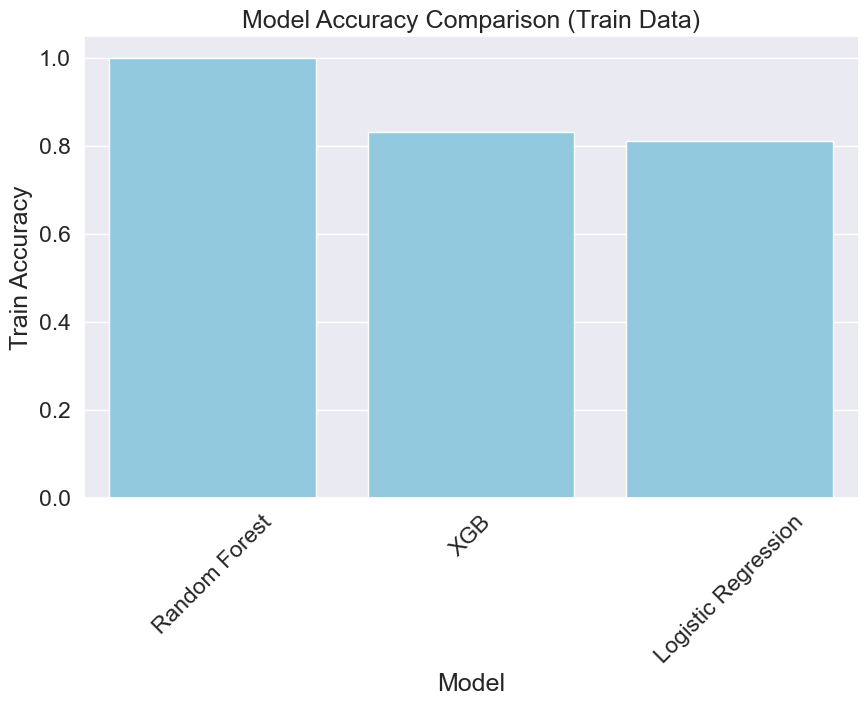

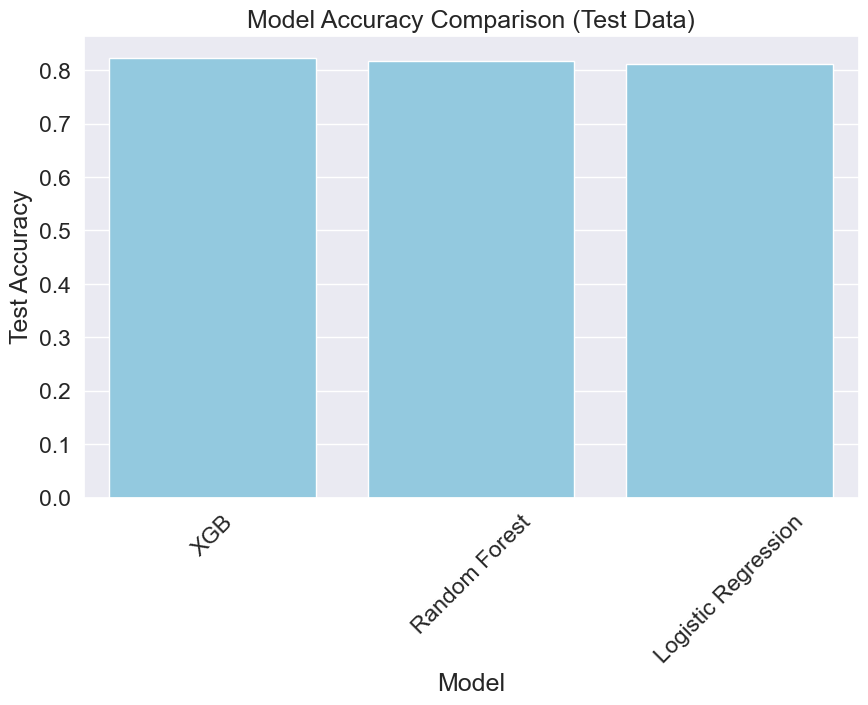

In [38]:
#plotting the results

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Train Accuracy", data=results_df.sort_values(by='Train Accuracy', ascending=False), color='skyblue')
plt.title("Model Accuracy Comparison (Train Data)")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x="Model", y="Test Accuracy", data=results_df.sort_values(by='Test Accuracy', ascending=False), color='skyblue')
plt.title("Model Accuracy Comparison (Test Data)")
plt.xticks(rotation=45)
plt.show()


In [40]:
X_submission = test_numeric.copy()

y_preds = model.predict(X_submission)

baseline_df = pd.DataFrame({
    'id' : test_id_placeholder,
    'loan_paid_back' : y_preds
})

baseline_df.to_csv("submission1.csv", index=False)
print("Success!")

Success!
